# **"EcoDriveAI+: Intelligent Driving Behavior and Energy Optimization System"**




**Public liberaries**

In [2]:

!pip install -q xgboost shap dash plotly openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 65.1 MB/s eta 0:00:00


In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)

from xgboost import XGBRegressor

import shap

import plotly.express as px
import plotly.graph_objects as go

from dash import Dash, dcc, html, Input, Output

**Data Exploration & Cleaning**

In [4]:
import pandas as pd
import os

# Assuming these are defined in a previous cell or as global constants
EV_FILE = "/content/EV_Energy_Consumption_Dataset.csv"
TARGET = "Energy_Consumption_kWh"

ev_raw = pd.read_csv(EV_FILE)

ev = ev_raw.copy()
ev = ev.rename(columns={
    "Acceleration_ms2": "Accel_longitudinal",
    "Battery_State_%": "Battery_SOC_percent"
})
for col in ev.columns:
    if ev[col].dtype == "object":
        converted = pd.to_numeric(ev[col], errors="coerce")
        if converted.notna().mean() > 0.80:
            ev[col] = converted
ev = ev.drop_duplicates().reset_index(drop=True)
if TARGET not in ev.columns:
    raise ValueError(
        f"Target column '{TARGET}' not found in EV dataset."
    )
ev = ev.dropna(subset=[TARGET]).reset_index(drop=True)
print("Clean EV shape:", ev.shape)

Clean EV shape: (5000, 19)


In [5]:
TESLA_FILE = "/content/tesla-model3.test01.csv"

if not os.path.exists(EV_FILE):
    raise FileNotFoundError(
        f"Could not find {EV_FILE}. "
        "Upload the file to your Colab/Jupyter working directory."
    )
if not os.path.exists(TESLA_FILE):
    raise FileNotFoundError(
        f"Could not find {TESLA_FILE}. "
        "Upload the file to your Colab/Jupyter working directory."
    )
ev_raw = pd.read_csv(EV_FILE)
tesla_raw = pd.read_csv(TESLA_FILE)
print("EV dataset shape:", ev_raw.shape)
print("Tesla dataset shape:", tesla_raw.shape)

EV dataset shape: (5000, 19)
Tesla dataset shape: (26140, 142)


In [6]:
print("\n========== EV COLUMNS ==========")
print(ev_raw.columns.tolist())

print("\n========== TESLA COLUMNS ==========")
print(tesla_raw.columns.tolist())

print("\n========== EV INFO ==========")
print(ev_raw.info())

print("\n========== TESLA INFO ==========")
print(tesla_raw.info())
ev = ev_raw.copy()
ev = ev.rename(columns={
    "Acceleration_ms2": "Accel_longitudinal",
    "Battery_State_%": "Battery_SOC_percent"
})
for col in ev.columns:
    if ev[col].dtype == "object":
        converted = pd.to_numeric(ev[col], errors="coerce")
        if converted.notna().mean() > 0.80:
            ev[col] = converted
ev = ev.drop_duplicates().reset_index(drop=True)
if TARGET not in ev.columns:
    raise ValueError(
        f"Target column '{TARGET}' not found in EV dataset."
    )
ev = ev.dropna(subset=[TARGET]).reset_index(drop=True)
print("Clean EV shape:", ev.shape)

tesla = tesla_raw.copy()
TESLA_RENAME = {
    "Time_Elapsed": "Time_Elapsed_s",
    "veh_speed (kph)": "Speed_kmh",
    "veh_odometer (km)": "Odometer_km",
    "pedal_accel (per)": "Pedal_Accel_percent",
    "veh_brake_state": "Brake_State",
    "DIF_elecPower (kW)": "Power_kW",
    "RCM_longitudinalAccel (m/s^2)": "Accel_longitudinal",
    "RCM_lateralAccel (m/s^2)": "Accel_lateral",
    "RCM_verticalAccel (m/s^2)": "Accel_vertical",
    "veh_steering_angle (deg)": "Steering_Angle_deg",
    "veh_steering_speedps (D/S)": "Steering_Speed",
    "BMS_TotalDischargeKWh (kWh)": "Battery_Discharge_kWh",
    "BMS_packCurrent (A)": "Battery_Current_A",
    "BMS_packVoltage (V)": "Battery_Voltage_V",
    "BMS_socAvg (per)": "Battery_SOC_percent",
    "ESP_brakeTorqueTarget (Nm)": "Brake_Torque_Nm"
}
tesla = tesla.rename(columns=TESLA_RENAME)
for col in tesla.columns:
    if tesla[col].dtype == "object":
        converted = pd.to_numeric(tesla[col], errors="coerce")

        if converted.notna().mean() > 0.80:
            tesla[col] = converted
tesla = tesla.drop_duplicates().reset_index(drop=True)
print("Clean Tesla shape:", tesla.shape)
print("\nAvailable standardized Tesla columns:")
print(tesla.columns.tolist())


========== EV COLUMNS ==========
['Vehicle_ID', 'Timestamp', 'Speed_kmh', 'Acceleration_ms2', 'Battery_State_%', 'Battery_Voltage_V', 'Battery_Temperature_C', 'Driving_Mode', 'Road_Type', 'Traffic_Condition', 'Slope_%', 'Weather_Condition', 'Temperature_C', 'Humidity_%', 'Wind_Speed_ms', 'Tire_Pressure_psi', 'Vehicle_Weight_kg', 'Distance_Travelled_km', 'Energy_Consumption_kWh']

========== TESLA COLUMNS ==========
['Time_Elapsed', 'Time (epoch)', 'Autoware Time', 'Time (abs)', 'veh_elevation (M)', 'gps_accuracy (m)', 'gps_latitude (deg)', 'gps_longitude (deg)', 'UI_gpsVehicleHeading (deg)', 'veh_state_drive', 'veh_odometer (km)', 'veh_speed (kph)', 'pedal_accel (per)', 'veh_gear', 'veh_gear_pos', 'DIF_elecPower (kW)', 'DIR_elecPower (kW)', 'DIF_axleSpeed (rpm)', 'DIR_axleSpeed (rpm)', 'DIF_torqueCommand (Nm)', 'DIF_torqueActual (Nm)', 'DIR_torqueCommand (Nm)', 'DIR_torqueActual (Nm)', 'motor_torque_front_request_2 (Nm)', 'motor_torque_front_actual_2 (Nm)', 'motor_torque_rear_request_

In [7]:


def add_common_features(df):
    """
    Create driving-behavior and dynamic-driving features.
    """

    df = df.copy()

    df["harsh_acceleration"] = (
        df["Accel_longitudinal"] > HARSH_ACCEL_THRESHOLD
    ).astype(int)

    df["harsh_braking"] = (
        df["Accel_longitudinal"] < HARSH_BRAKE_THRESHOLD
    ).astype(int)

    df["eco_acceleration"] = (
        df["Accel_longitudinal"].between(
            ECO_ACCEL_MIN,
            ECO_ACCEL_MAX
        )
    ).astype(int)

    df["Acceleration_Magnitude"] = np.abs(
        df["Accel_longitudinal"]
    )

    if "Time_Elapsed_s" in df.columns:

        dt = df["Time_Elapsed_s"].diff()

        dt = dt.replace(0, np.nan)

        df["Jerk"] = (
            df["Accel_longitudinal"].diff() / dt
        )

    else:

        df["Jerk"] = df["Accel_longitudinal"].diff()

    df["Jerk"] = df["Jerk"].replace(
        [np.inf, -np.inf],
        np.nan
    )

    df["Jerk"] = df["Jerk"].fillna(0)

    df["Absolute_Jerk"] = np.abs(df["Jerk"])

    df["Speed_Change"] = (
        df["Speed_kmh"].diff().abs()
    )

    df["Speed_Change"] = df["Speed_Change"].fillna(0)

    df["Rolling_Speed_STD"] = (
        df["Speed_kmh"]
        .rolling(ROLLING_WINDOW, min_periods=1)
        .std()
        .fillna(0)
    )

    df["Rolling_Accel_STD"] = (
        df["Accel_longitudinal"]
        .rolling(ROLLING_WINDOW, min_periods=1)
        .std()
        .fillna(0)
    )

    df["Traffic_Stress"] = (
        df["Speed_Change"]
        .rolling(ROLLING_WINDOW, min_periods=1)
        .mean()
        .fillna(0)
    )
    q1 = df["Traffic_Stress"].quantile(0.33)
    q2 = df["Traffic_Stress"].quantile(0.66)

    def traffic_label(x):

        if x <= q1:
            return "Light"

        elif x <= q2:
            return "Moderate"

        return "Heavy"

    df["Traffic_Condition"] = (
        df["Traffic_Stress"]
        .apply(traffic_label)
    )


    df["Aggressive_Score"] = (
        df["harsh_acceleration"] +
        df["harsh_braking"] +
        (df["Absolute_Jerk"] >
         df["Absolute_Jerk"].quantile(0.90)).astype(int)
    )

    df["Eco_Driving_Flag"] = df["eco_acceleration"]

    return df


EV feature engineering complete.

New columns:
['Vehicle_ID', 'Timestamp', 'Speed_kmh', 'Accel_longitudinal', 'Battery_SOC_percent', 'Battery_Voltage_V', 'Battery_Temperature_C', 'Driving_Mode', 'Road_Type', 'Traffic_Condition', 'Slope_%', 'Weather_Condition', 'Temperature_C', 'Humidity_%', 'Wind_Speed_ms', 'Tire_Pressure_psi', 'Vehicle_Weight_kg', 'Distance_Travelled_km', 'Energy_Consumption_kWh', 'harsh_acceleration', 'harsh_braking', 'eco_acceleration', 'Acceleration_Magnitude', 'Jerk', 'Absolute_Jerk', 'Speed_Change', 'Rolling_Speed_STD', 'Rolling_Accel_STD', 'Traffic_Stress', 'Aggressive_Score', 'Eco_Driving_Flag']
       Energy_Consumption_kWh  Energy_kWh_per_100km
count             5000.000000           5000.000000
mean                 8.437983             87.268893
std                  2.184809            291.856060
min                  1.881426              8.613988
25%                  6.771081             24.637806
50%                  8.455746             34.156300
75%     

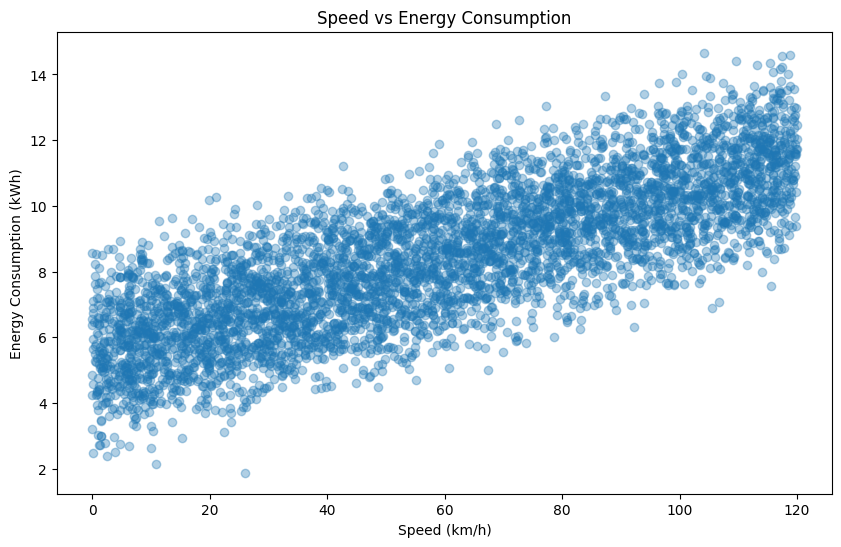

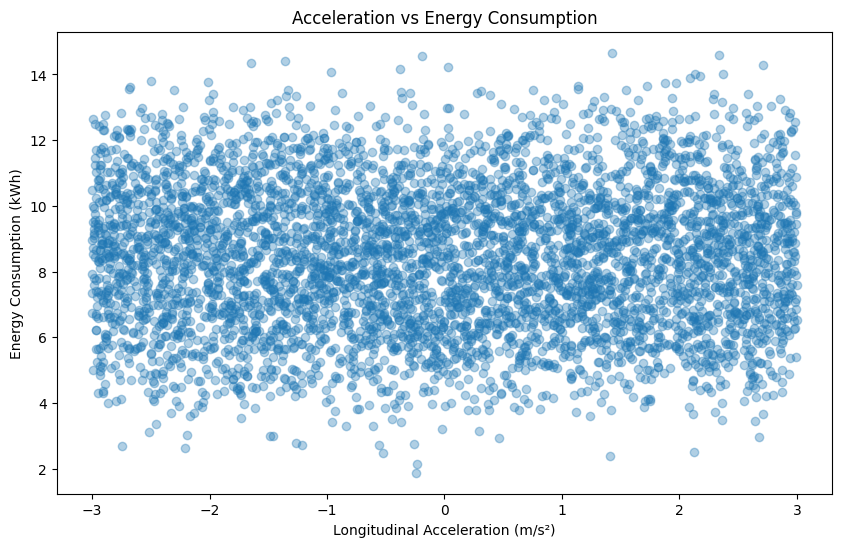

In [8]:
HARSH_ACCEL_THRESHOLD = 2.0
HARSH_BRAKE_THRESHOLD = -2.5
ECO_ACCEL_MIN = -0.5
ECO_ACCEL_MAX = 0.5
ROLLING_WINDOW = 5

required_ev = [
    "Speed_kmh",
    "Accel_longitudinal"
]
missing_ev = [
    col for col in required_ev
    if col not in ev.columns
]
if missing_ev:
    raise ValueError(
        f"Missing required EV columns: {missing_ev}"
    )

ev = add_common_features(ev)
print("EV feature engineering complete.")
print("\nNew columns:")
print(ev.columns.tolist())
if "Distance_Travelled_km" in ev.columns:

    ev["Energy_kWh_per_100km"] = np.where(
        ev["Distance_Travelled_km"] > 0,
        (
            ev[TARGET] /
            ev["Distance_Travelled_km"]
        ) * 100,
        np.nan
    )
else:
    ev["Energy_kWh_per_100km"] = np.nan
print(
    ev[
        [TARGET, "Energy_kWh_per_100km"]
    ].describe()
)
plt.figure(figsize=(10, 6))

plt.scatter(
    ev["Speed_kmh"],
    ev[TARGET],
    alpha=0.35
)

plt.xlabel("Speed (km/h)")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Speed vs Energy Consumption")

plt.show()
plt.figure(figsize=(10, 6))

plt.scatter(
    ev["Accel_longitudinal"],
    ev[TARGET],
    alpha=0.35
)

plt.xlabel("Longitudinal Acceleration (m/s²)")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Acceleration vs Energy Consumption")

plt.show()

In [9]:
numeric_ev = ev.select_dtypes(
    include=np.number
)

correlations = (
    numeric_ev
    .corr()[TARGET]
    .sort_values(
        ascending=False
    )
)

print(
    correlations
)

possible_vehicle_columns = [
    "Vehicle_ID",
    "vehicle_id",
    "VehicleID",
    "vehicleID",
    "VIN",
    "vin"
]

vehicle_column = None

for col in possible_vehicle_columns:

    if col in ev.columns:
        vehicle_column = col
        break

if vehicle_column:

    ev["Model_Group"] = (
        ev[vehicle_column]
        .astype(str)
    )

    print(
        "Using real vehicle grouping:",
        vehicle_column
    )

else:
    ev["Model_Group"] = (
        np.arange(len(ev)) // 10
    ).astype(str)

    print(
        "WARNING: No real Vehicle_ID found."
    )

    print(
        "Fallback groups are being used only "
        "to keep the pipeline executable."
    )

Energy_Consumption_kWh    1.000000
Speed_kmh                 0.792811
Distance_Travelled_km     0.465870
Humidity_%                0.172985
Battery_Temperature_C     0.141392
Slope_%                   0.086668
Wind_Speed_ms             0.073352
Acceleration_Magnitude    0.043462
Driving_Mode              0.033469
Aggressive_Score          0.029154
harsh_braking             0.023992
Rolling_Speed_STD         0.021997
Road_Type                 0.018555
Battery_Voltage_V         0.010096
Rolling_Accel_STD         0.005127
Absolute_Jerk             0.004932
Speed_Change              0.001528
Vehicle_ID                0.001098
harsh_acceleration       -0.001892
Vehicle_Weight_kg        -0.002189
Jerk                     -0.002857
Traffic_Stress           -0.004434
Accel_longitudinal       -0.006524
Weather_Condition        -0.019388
Temperature_C            -0.033740
Tire_Pressure_psi        -0.036304
Eco_Driving_Flag         -0.041718
eco_acceleration         -0.041718
Energy_kWh_per_100km

**model features**

In [10]:
candidate_numeric_features = [
    "Speed_kmh",
    "Accel_longitudinal",
    "Acceleration_Magnitude",
    "Jerk",
    "Absolute_Jerk",
    "Rolling_Speed_STD",
    "Rolling_Accel_STD",
    "Traffic_Stress",
    "Aggressive_Score",
    "Battery_SOC_percent",
    "Battery_Voltage_V",
    "Battery_Temperature_C",
    "Temperature_C",
    "Humidity_%",
    "Wind_Speed_ms",
    "Tire_Pressure_psi",
    "Vehicle_Weight_kg",
    "Slope_%",
    "Distance_Travelled_km"
]

candidate_categorical_features = [
    "Weather_Condition",
    "Traffic_Condition"
]

numeric_features = [
    col for col in candidate_numeric_features
    if col in ev.columns
]

categorical_features = [
    col for col in candidate_categorical_features
    if col in ev.columns
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Speed_kmh', 'Accel_longitudinal', 'Acceleration_Magnitude', 'Jerk', 'Absolute_Jerk', 'Rolling_Speed_STD', 'Rolling_Accel_STD', 'Traffic_Stress', 'Aggressive_Score', 'Battery_SOC_percent', 'Battery_Voltage_V', 'Battery_Temperature_C', 'Temperature_C', 'Humidity_%', 'Wind_Speed_ms', 'Tire_Pressure_psi', 'Vehicle_Weight_kg', 'Slope_%', 'Distance_Travelled_km']

Categorical features:
['Weather_Condition', 'Traffic_Condition']


In [11]:
for col in categorical_features:
    ev[col] = ev[col].astype(str)
model_features = (
    numeric_features +
    categorical_features
)

model_df = ev[
    model_features +
    [TARGET, "Model_Group"]
].copy()

model_df = model_df.dropna(
    subset=[TARGET]
)

X = model_df[model_features]

y = model_df[TARGET]

groups = model_df["Model_Group"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 21)
y shape: (5000,)


In [12]:
RANDOM_STATE = 42

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    group_splitter.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print(
    "Training groups:",
    groups.iloc[train_idx].nunique()
)

print(
    "Testing groups:",
    groups.iloc[test_idx].nunique()
)

Training rows: 4003
Testing rows: 997
Training groups: 791
Testing groups: 198


In [13]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)
try:

    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

except TypeError:

    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            categorical_encoder
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

In [14]:
models = {
    "Dummy Baseline": DummyRegressor(
        strategy="mean"
    ),
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=2,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

In [15]:
def evaluate_model(
    name,
    estimator,
    X_train,
    y_train,
    X_test,
    y_test
):

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator)
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Pipeline": pipeline,
        "Predictions": predictions
    }

In [16]:

results = []

trained_models = {}

predictions = {}

for name, estimator in models.items():

    print(
        f"\nTraining {name}..."
    )

    result = evaluate_model(
        name,
        estimator,
        X_train,
        y_train,
        X_test,
        y_test
    )

    results.append({
        "Model": result["Model"],
        "MAE": result["MAE"],
        "RMSE": result["RMSE"],
        "R2": result["R2"]
    })

    trained_models[name] = (
        result["Pipeline"]
    )

    predictions[name] = (
        result["Predictions"]
    )

results_df = pd.DataFrame(
    results
).sort_values(
    "RMSE"
).reset_index(drop=True)

display(results_df)


Training Dummy Baseline...

Training Linear Regression...

Training Random Forest...

Training HistGradientBoosting...

Training XGBoost...


,Model,MAE,RMSE,R2
0,Linear Regression,0.417291,0.518212,0.940696
1,HistGradientBoosting,0.453949,0.565527,0.929372
2,XGBoost,0.454050,0.568135,0.928719
3,Random Forest,0.516015,0.648525,0.907120
4,Dummy Baseline,1.761616,2.133218,-0.004939


In [17]:
best_model_name = (
    results_df
    .iloc[0]["Model"]
)

best_pipeline = (
    trained_models[best_model_name]
)

best_predictions = (
    predictions[best_model_name]
)

print(
    "BEST MODEL:",
    best_model_name
)

print(
    "\nBest model metrics:"
)

display(
    results_df[
        results_df["Model"] ==
        best_model_name
    ]
)

BEST MODEL: Linear Regression

Best model metrics:


,Model,MAE,RMSE,R2
0,Linear Regression,0.417291,0.518212,0.940696


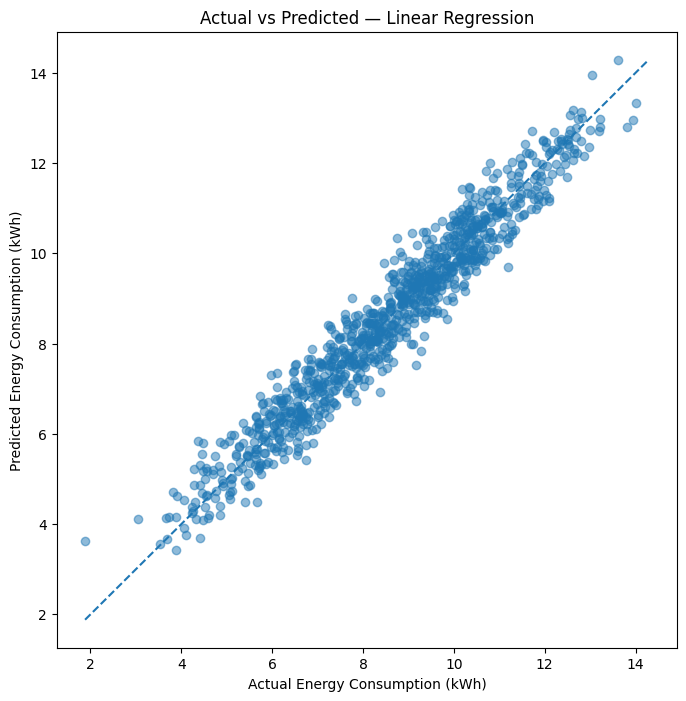

In [18]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

minimum = min(
    y_test.min(),
    best_predictions.min()
)

maximum = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual Energy Consumption (kWh)"
)

plt.ylabel(
    "Predicted Energy Consumption (kWh)"
)

plt.title(
    f"Actual vs Predicted — {best_model_name}"
)

plt.show()

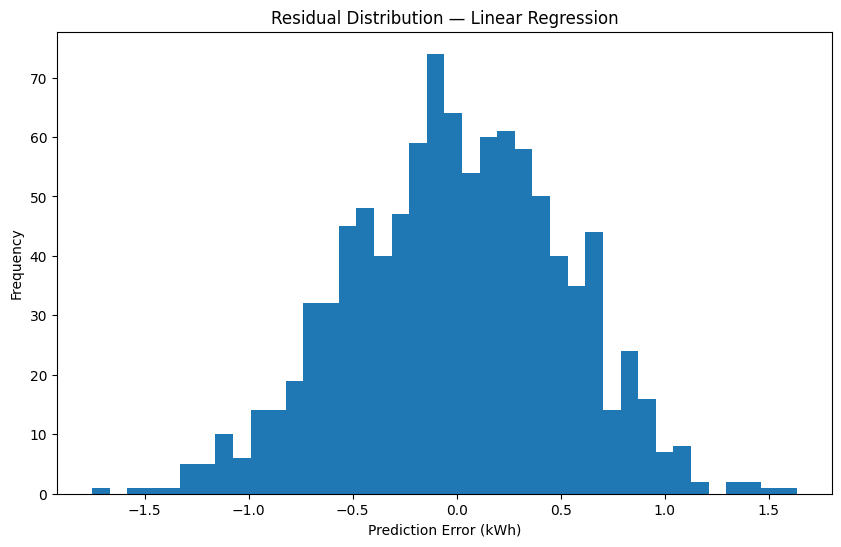

In [19]:
residuals = (
    y_test.values -
    best_predictions
)

plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=40
)

plt.xlabel("Prediction Error (kWh)")
plt.ylabel("Frequency")
plt.title(
    f"Residual Distribution — {best_model_name}"
)

plt.show()

In [20]:
model_object = (
    best_pipeline
    .named_steps["model"]
)

preprocessor_fitted = (
    best_pipeline
    .named_steps["preprocessor"]
)

try:

    feature_names = (
        preprocessor_fitted
        .get_feature_names_out()
    )

    if hasattr(
        model_object,
        "feature_importances_"
    ):

        importance_values = (
            model_object
            .feature_importances_
        )

        feature_importance = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importance_values
        }).sort_values(
            "Importance",
            ascending=False
        )

        display(
            feature_importance.head(20)
        )

except Exception as e:

    print(
        "Feature importance unavailable:",
        e
    )

if "feature_importance" in locals():

    top_features = (
        feature_importance
        .head(15)
        .sort_values("Importance")
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(
        f"Top Energy Consumption Drivers — {best_model_name}"
    )

    plt.show()

In [21]:

if best_model_name in [
    "Random Forest",
    "XGBoost"
]:
    X_test_transformed = (
        preprocessor_fitted
        .transform(X_test)
    )

    feature_names = (
        preprocessor_fitted
        .get_feature_names_out()
    )

    X_test_transformed_df = pd.DataFrame(
        X_test_transformed,
        columns=feature_names,
        index=X_test.index
    )

    explainer = shap.TreeExplainer(
        model_object
    )

    shap_values = explainer(
        X_test_transformed_df
    )

    print("SHAP analysis generated.")
if "shap_values" in locals():
    shap.summary_plot(
        shap_values,
        X_test_transformed_df,
        max_display=20
    )

In [22]:
tesla_required = [
    "Speed_kmh",
    "Accel_longitudinal"
]

missing_tesla = [
    col for col in tesla_required
    if col not in tesla.columns
]

if missing_tesla:

    raise ValueError(f"Tesla dataset is missing: {missing_tesla}")

# Convert 'Time_Elapsed_s' from HH:MM:SS string to total seconds (float)
if "Time_Elapsed_s" in tesla.columns:
    def time_to_seconds(time_str):
        if pd.isna(time_str):
            return np.nan
        parts = str(time_str).split(':')
        if len(parts) == 3:
            h, m, s = map(float, parts)
            return h * 3600 + m * 60 + s
        return np.nan

    tesla["Time_Elapsed_s"] = tesla["Time_Elapsed_s"].apply(time_to_seconds)

tesla = add_common_features(
    tesla
)

print(
    "Tesla feature engineering complete."
)


tesla_model = pd.DataFrame(
    index=tesla.index
)

for col in numeric_features:

    if col in tesla.columns:

        tesla_model[col] = (
            tesla[col]
        )

    else:

        tesla_model[col] = np.nan


for col in categorical_features:

    if col in tesla.columns:

        tesla_model[col] = (
            tesla[col].astype(str)
        )

    else:

        tesla_model[col] = "Unknown"


print("Tesla model input shape:",
    tesla_model.shape
)

tesla_predictions = (best_pipeline.predict(tesla_model))

tesla["Predicted_Energy_kWh"] = (
    tesla_predictions
)

print(
    tesla[
        [
            "Speed_kmh",
            "Accel_longitudinal",
            "Predicted_Energy_kWh"
        ]
    ].head(10)
)

Tesla feature engineering complete.
Tesla model input shape: (26140, 21)
   Speed_kmh  Accel_longitudinal  Predicted_Energy_kWh
0        0.0              -0.124              4.942581
1        0.0              -0.126              4.942770
2        0.0              -0.145              4.944537
3        0.0              -0.139              4.943955
4        0.0              -0.115              4.941645
5        0.0              -0.121              4.942242
6        0.0              -0.123              4.942439
7        0.0              -0.064              4.936701
8        0.0              -0.092              4.939385
9        0.0              -0.108              4.940907


In [23]:
if "Battery_Discharge_kWh" in tesla.columns:
    discharge_start = (tesla["Battery_Discharge_kWh"].dropna().iloc[0])

    discharge_end = (tesla["Battery_Discharge_kWh"].dropna().iloc[-1])

    observed_discharge = (discharge_end -discharge_start)

    print(
        f"Observed cumulative battery discharge: "
        f"{observed_discharge:.3f} kWh"
    )

else:

    observed_discharge = np.nan

    print(
        "Battery discharge column unavailable."
    )

if "Odometer_km" in tesla.columns:

    odometer = (
        tesla["Odometer_km"]
        .dropna()
    )

    if len(odometer) > 1:

        trip_distance = (
            odometer.max() -
            odometer.min()
        )

        print(
            f"Observed Tesla trip distance: "
            f"{trip_distance:.3f} km"
        )

    else:

        trip_distance = np.nan

else:

    trip_distance = np.nan

    print(
        "Odometer unavailable."
    )

if (
    not np.isnan(observed_discharge)
    and not np.isnan(trip_distance)
    and trip_distance > 0
):

    observed_energy_intensity = (
        observed_discharge /
        trip_distance
    ) * 100

    print(
        "Observed battery discharge intensity:",
        round(
            observed_energy_intensity,
            2
        ),
        "kWh/100 km"
    )

else:

    observed_energy_intensity = np.nan

Observed cumulative battery discharge: 10.000 kWh
Observed Tesla trip distance: 52.200 km
Observed battery discharge intensity: 19.16 kWh/100 km


In [24]:
behavior_features = [
    "Speed_kmh",
    "Accel_longitudinal",
    "Absolute_Jerk",
    "Rolling_Speed_STD",
    "Rolling_Accel_STD",
    "harsh_acceleration",
    "harsh_braking",
    "Eco_Driving_Flag"
]

behavior_features = [
    col for col in behavior_features
    if col in tesla.columns
]

behavior_df = tesla[
    behavior_features
].copy()

behavior_df = behavior_df.replace(
    [np.inf, -np.inf],
    np.nan
)

behavior_df = behavior_df.fillna(
    behavior_df.median(numeric_only=True)
)

behavior_scaler = StandardScaler()

behavior_scaled = (
    behavior_scaler
    .fit_transform(
        behavior_df
    )
)

print(
    "Behavior features:",
    behavior_features
)

Behavior features: ['Speed_kmh', 'Accel_longitudinal', 'Absolute_Jerk', 'Rolling_Speed_STD', 'Rolling_Accel_STD', 'harsh_acceleration', 'harsh_braking', 'Eco_Driving_Flag']


In [25]:
silhouette_results = []

for k in range(2, 6):

    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = km.fit_predict(
        behavior_scaled
    )

    score = silhouette_score(
        behavior_scaled,
        labels
    )

    silhouette_results.append({
        "K": k,
        "Silhouette_Score": score
    })

silhouette_df = pd.DataFrame(
    silhouette_results
)

display(
    silhouette_df
)

best_k = int(
    silhouette_df
    .sort_values(
        "Silhouette_Score",
        ascending=False
    )
    .iloc[0]["K"]
)

print(
    "Selected number of clusters:",
    best_k
)

# Re-run KMeans with the best K and assign clusters to the tesla DataFrame
best_km = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)

tesla["Behavior_Cluster"] = (
    best_km.fit_predict(behavior_scaled)
)

# The duplicate code below is not needed since the logic is already above.
# silhouette_results = []

# for k in range(2, 6):

#     km = KMeans(
#         n_clusters=k,
#         random_state=RANDOM_STATE,
#         n_init=20
#     )

#     labels = km.fit_predict(
#         behavior_scaled
#     )

#     score = silhouette_score(
#         behavior_scaled,
#         labels
#     )

#     silhouette_results.append({
#         "K": k,
#         "Silhouette_Score": score
#     })

# silhouette_df = pd.DataFrame(
#     silhouette_results
# )

# display(
#     silhouette_df
# )

# best_k = int(
#     silhouette_df
#     .sort_values(
#         "Silhouette_Score",
#         ascending=False
#     )
#     .iloc[0]["K"]
# )

# print(
#     "Selected number of clusters:",
#     best_k
# )

,K,Silhouette_Score
0,2,0.646977
1,3,0.639480
2,4,0.628998
3,5,0.426605


Selected number of clusters: 2


In [26]:

cluster_profile = (
    tesla
    .groupby("Behavior_Cluster")[
        behavior_features +
        ["Predicted_Energy_kWh"]
    ]
    .mean()
    .round(3)
)

display(
    cluster_profile
)


profile = (
    tesla
    .groupby("Behavior_Cluster")
    .agg({
        "Accel_longitudinal": "mean",
        "Absolute_Jerk": "mean",
        "Rolling_Accel_STD": "mean",
        "harsh_acceleration": "mean",
        "harsh_braking": "mean",
        "Eco_Driving_Flag": "mean"
    })
)

# Normalize ranking components
for col in [
    "Accel_longitudinal",
    "Absolute_Jerk",
    "Rolling_Accel_STD",
    "harsh_acceleration",
    "harsh_braking"
]:

    min_value = profile[col].min()
    max_value = profile[col].max()

    if max_value != min_value:

        profile[
            col + "_norm"
        ] = (
            profile[col] -
            min_value
        ) / (
            max_value -
            min_value
        )

    else:

        profile[
            col + "_norm"
        ] = 0


profile["Aggression_Index"] = (
    profile["Absolute_Jerk_norm"] +
    profile["Rolling_Accel_STD_norm"] +
    profile["harsh_acceleration_norm"] +
    profile["harsh_braking_norm"]
) / 4


profile["Eco_Index"] = (
    1 -
    profile["Aggression_Index"]
)

display(
    profile.sort_values(
        "Aggression_Index"
    )
)


ordered_clusters = (
    profile
    .sort_values(
        "Aggression_Index"
    )
    .index
    .tolist()
)

if len(ordered_clusters) == 3:

    behavior_mapping = {
        ordered_clusters[0]: "Eco-Friendly",
        ordered_clusters[1]: "Normal",
        ordered_clusters[2]: "Aggressive"
    }

else:

    behavior_mapping = {}

    for i, cluster in enumerate(
        ordered_clusters
    ):

        if i == 0:
            label = "Eco-Friendly"

        elif i == len(ordered_clusters) - 1:
            label = "Aggressive"

        else:
            label = f"Intermediate-{i}"

        behavior_mapping[cluster] = label


tesla["Driving_Behavior"] = (
    tesla["Behavior_Cluster"]
    .map(behavior_mapping)
)

print(
    behavior_mapping
)
behavior_distribution = (
    tesla["Driving_Behavior"]
    .value_counts()
    .rename_axis("Driving_Behavior")
    .reset_index(
        name="Records"
    )
)

behavior_distribution["Percentage"] = (
    behavior_distribution["Records"] /
    len(tesla) *
    100
)

display(
    behavior_distribution
)

behavior_energy = (
    tesla
    .groupby("Driving_Behavior")
    ["Predicted_Energy_kWh"]
    .agg(
        ["mean", "median", "std", "count"]
    )
    .reset_index()
)

display(
    behavior_energy
)

traffic_energy = (
    tesla
    .groupby("Traffic_Condition")
    ["Predicted_Energy_kWh"]
    .agg(
        ["mean", "median", "count"]
    )
    .reset_index()
)

display(
    traffic_energy
)

,Speed_kmh,Accel_longitudinal,Absolute_Jerk,Rolling_Speed_STD,Rolling_Accel_STD,harsh_acceleration,harsh_braking,Eco_Driving_Flag,Predicted_Energy_kWh
Behavior_Cluster,,,,,,,,,
0,74.838,0.027,0.009,0.051,0.078,0.000,0.000,1.000,8.800
1,46.546,-0.070,0.015,0.559,0.150,0.027,0.025,0.012,7.502


,Accel_longitudinal,Absolute_Jerk,Rolling_Accel_STD,harsh_acceleration,harsh_braking,Eco_Driving_Flag,Accel_longitudinal_norm,Absolute_Jerk_norm,Rolling_Accel_STD_norm,harsh_acceleration_norm,harsh_braking_norm,Aggression_Index,Eco_Index
Behavior_Cluster,,,,,,,,,,,,,
0,0.027049,0.009105,0.077933,0.000000,0.000000,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.070311,0.014861,0.150098,0.027223,0.024682,0.011978,0.0,1.0,1.0,1.0,1.0,1.0,0.0


{0: 'Eco-Friendly', 1: 'Aggressive'}


,Driving_Behavior,Records,Percentage
0,Eco-Friendly,23385,89.460597
1,Aggressive,2755,10.539403


,Driving_Behavior,mean,median,std,count
0,Aggressive,7.502272,7.489092,1.471132,2755
1,Eco-Friendly,8.799867,9.403465,1.540969,23385


,Traffic_Condition,mean,median,count
0,Heavy,8.213983,8.280942,7741
1,Light,8.554577,9.409209,11436
2,Moderate,9.340665,9.467228,6963


In [27]:

score_components = pd.DataFrame(
    index=tesla.index
)

harsh_rate = (
    tesla["harsh_acceleration"] +
    tesla["harsh_braking"]
)


jerk_reference = (
    tesla["Absolute_Jerk"]
    .quantile(0.90)
)

if jerk_reference > 0:

    jerk_penalty = (
        tesla["Absolute_Jerk"] /
        jerk_reference
    ).clip(0, 1)

else:

    jerk_penalty = 0


speed_reference = (
    tesla["Rolling_Speed_STD"]
    .quantile(0.90)
)

if speed_reference > 0:

    speed_penalty = (
        tesla["Rolling_Speed_STD"] /
        speed_reference
    ).clip(0, 1)

else:

    speed_penalty = 0


tesla["EcoDrive_Score"] = (
    100
    - 35 * harsh_rate.clip(0, 1)
    - 35 * jerk_penalty
    - 30 * speed_penalty
)

tesla["EcoDrive_Score"] = (
    tesla["EcoDrive_Score"]
    .clip(0, 100)
)

print(
    tesla["EcoDrive_Score"].describe()
)

def score_category(score):

    if score >= 80:
        return "Excellent"

    elif score >= 65:
        return "Good"

    elif score >= 50:
        return "Moderate"

    return "Needs Improvement"


tesla["EcoDrive_Category"] = (
    tesla["EcoDrive_Score"]
    .apply(score_category)
)

display(
    tesla[
        [
            "EcoDrive_Score",
            "EcoDrive_Category",
            "Driving_Behavior"
        ]
    ].head(20)
)

count    26140.000000
mean        91.546704
std         10.257532
min         35.000000
25%         89.183346
50%         94.803848
75%        100.000000
max        100.000000
Name: EcoDrive_Score, dtype: float64


,EcoDrive_Score,EcoDrive_Category,Driving_Behavior
0,100.0,Excellent,Eco-Friendly
1,100.0,Excellent,Eco-Friendly
2,100.0,Excellent,Eco-Friendly
3,100.0,Excellent,Eco-Friendly
4,100.0,Excellent,Eco-Friendly
5,100.0,Excellent,Eco-Friendly
6,100.0,Excellent,Eco-Friendly
7,100.0,Excellent,Eco-Friendly
8,100.0,Excellent,Eco-Friendly
9,100.0,Excellent,Eco-Friendly


In [28]:


counterfactual = tesla_model.copy()

# Reduce acceleration magnitude
counterfactual[
    "Accel_longitudinal"
] = (
    counterfactual[
        "Accel_longitudinal"
    ] * 0.65
)

# Recalculate related variables
if "Acceleration_Magnitude" in counterfactual.columns:

    counterfactual[
        "Acceleration_Magnitude"
    ] = np.abs(
        counterfactual[
            "Accel_longitudinal"
        ]
    )

if "Aggressive_Score" in counterfactual.columns:

    counterfactual[
        "Aggressive_Score"
    ] = 0


if "Jerk" in counterfactual.columns:

    counterfactual["Jerk"] = (
        counterfactual[
            "Jerk"
        ] * 0.65
    )

if "Absolute_Jerk" in counterfactual.columns:

    counterfactual[
        "Absolute_Jerk"
    ] = np.abs(
        counterfactual["Jerk"]
    )


eco_predictions = (
    best_pipeline
    .predict(counterfactual)
)

tesla[
    "Counterfactual_Eco_Energy_kWh"
] = eco_predictions


tesla["Estimated_Energy_Saving_kWh"] = (
    tesla["Predicted_Energy_kWh"] -
    tesla["Counterfactual_Eco_Energy_kWh"]
)

tesla["Estimated_Saving_Percent"] = np.where(

    tesla["Predicted_Energy_kWh"] > 0,

    (
        tesla["Estimated_Energy_Saving_kWh"] /
        tesla["Predicted_Energy_kWh"]
    ) * 100,

    np.nan
)

print(
    tesla[
        [
            "Predicted_Energy_kWh",
            "Counterfactual_Eco_Energy_kWh",
            "Estimated_Energy_Saving_kWh",
            "Estimated_Saving_Percent"
        ]
    ].describe()
)


average_current = (
    tesla["Predicted_Energy_kWh"]
    .mean()
)

average_eco = (
    tesla["Counterfactual_Eco_Energy_kWh"]
    .mean()
)

potential_reduction = (
    (
        average_current -
        average_eco
    )
    /
    average_current
) * 100

print(
    f"Average current predicted energy: "
    f"{average_current:.4f} kWh"
)

print(
    f"Average eco-driving scenario: "
    f"{average_eco:.4f} kWh"
)

print(
    f"Model-based potential reduction: "
    f"{potential_reduction:.2f}%"
)

def generate_recommendation(row):

    recommendations = []

    if row["harsh_acceleration"] == 1:

        recommendations.append(
            "Reduce sudden acceleration."
        )

    if row["harsh_braking"] == 1:

        recommendations.append(
            "Anticipate traffic and brake more smoothly."
        )

    if row["Absolute_Jerk"] > tesla["Absolute_Jerk"].quantile(0.90):

        recommendations.append(
            "Maintain smoother changes in acceleration."
        )

    if row["Rolling_Speed_STD"] > tesla["Rolling_Speed_STD"].quantile(0.90):

        recommendations.append(
            "Reduce speed fluctuations."
        )

    if row["Driving_Behavior"] == "Aggressive":

        recommendations.append(
            "Adopt a more consistent eco-driving style."
        )

    if not recommendations:

        recommendations.append(
            "Continue maintaining smooth driving behavior."
        )

    return " ".join(
        recommendations
    )


tesla["Recommendation"] = (
    tesla.apply(
        generate_recommendation,
        axis=1
    )
)

display(
    tesla[
        [
            "Driving_Behavior",
            "EcoDrive_Score",
            "Recommendation"
        ]
    ].head(20)
)

def predict_route_energy(
    route_df,
    model_pipeline
):

    route_input = pd.DataFrame(
        index=route_df.index
    )

    for col in numeric_features:

        if col in route_df.columns:

            route_input[col] = (
                route_df[col]
            )

        else:

            route_input[col] = np.nan

    for col in categorical_features:

        if col in route_df.columns:

            route_input[col] = (
                route_df[col].astype(str)
            )

        else:

            route_input[col] = "Unknown"

    predictions = (
        model_pipeline
        .predict(route_input)
    )

    route_df = route_df.copy()

    route_df[
        "Predicted_Energy_kWh"
    ] = predictions

    return route_df


def predict_route_energy(
    route_df,
    model_pipeline
):

    route_input = pd.DataFrame(
        index=route_df.index
    )

    for col in numeric_features:

        if col in route_df.columns:

            route_input[col] = (
                route_df[col]
            )

        else:

            route_input[col] = np.nan

    for col in categorical_features:

        if col in route_df.columns:

            route_input[col] = (
                route_df[col].astype(str)
            )

        else:

            route_input[col] = "Unknown"

    predictions = (
        model_pipeline
        .predict(route_input)
    )

    route_df = route_df.copy()

    route_df[
        "Predicted_Energy_kWh"
    ] = predictions

    return route_df

       Predicted_Energy_kWh  Counterfactual_Eco_Energy_kWh  \
count          26140.000000                   26140.000000   
mean               8.663108                       8.655480   
std                1.584643                       1.587727   
min                4.750792                       4.750559   
25%                7.960211                       7.949205   
50%                9.364130                       9.358348   
75%                9.555936                       9.551507   
max               10.531786                      10.488793   

       Estimated_Energy_Saving_kWh  Estimated_Saving_Percent  
count                 26140.000000              26140.000000  
mean                      0.007628                  0.099588  
std                       0.011859                  0.169825  
min                       0.000000                  0.000000  
25%                       0.001947                  0.021328  
50%                       0.004164                  0.047298  


,Driving_Behavior,EcoDrive_Score,Recommendation
0,Eco-Friendly,100.0,Continue maintaining smooth driving behavior.
1,Eco-Friendly,100.0,Continue maintaining smooth driving behavior.
2,Eco-Friendly,100.0,Continue maintaining smooth driving behavior.
3,Eco-Friendly,100.0,Continue maintaining smooth driving behavior.
4,Eco-Friendly,100.0,Continue maintaining smooth driving behavior.
5,Eco-Friendly,100.0,Continue maintaining smooth driving behavior.
6,Eco-Friendly,100.0,Continue maintaining smooth driving behavior.
7,Eco-Friendly,100.0,Continue maintaining smooth driving behavior.
8,Eco-Friendly,100.0,Continue maintaining smooth driving behavior.
9,Eco-Friendly,100.0,Continue maintaining smooth driving behavior.


In [29]:
def rank_routes(
    route_scenarios,
    model_pipeline
):
    results = []
    for route_name, route_df in route_scenarios.items():
        predicted_route_df = predict_route_energy(
            route_df,
            model_pipeline
        )
        total_energy = (
            predicted_route_df["Predicted_Energy_kWh"].sum()
        )
        average_speed = (
            predicted_route_df["Speed_kmh"].mean()
        )
        distance_travelled = (
            route_df["Distance_Travelled_km"].sum()
        )

        if distance_travelled > 0:
            energy_per_100km = (
                total_energy /
                distance_travelled
            ) * 100
        else:
            energy_per_100km = np.nan
        results.append({
            "Route": route_name,
            "Total_Energy_kWh": total_energy,
            "Average_Speed_kmh": average_speed,
            "Distance_km": distance_travelled,
            "Energy_per_100km": energy_per_100km
        })

    results_df = pd.DataFrame(
        results
    ).sort_values(
        "Total_Energy_kWh"
    ).reset_index(
        drop=True
    )
    return results_df

route_template = {
    "Speed_kmh": 60,
    "Accel_longitudinal": 0.5,
    "Battery_SOC_percent": 60,
    "Battery_Voltage_V": 350,
    "Distance_Travelled_km": 1,
    "Temperature_C": 15,
    "Humidity_%": 60,
    "Wind_Speed_ms": 3,
    "Tire_Pressure_psi": 35,
    "Vehicle_Weight_kg": 1800,
    "Slope_%": 1,
    "Traffic_Condition": "Light",
    "Weather_Condition": "Normal"
}

route_a = pd.DataFrame(
    [route_template] * 15
)

route_a["Speed_kmh"] = 75
route_a["Slope_%"] = 2.5
route_a["Traffic_Condition"] = "Heavy"

route_b = pd.DataFrame(
    [route_template] * 18
)

route_b["Speed_kmh"] = 55
route_b["Slope_%"] = 0.8
route_b["Traffic_Condition"] = "Moderate"

route_c = pd.DataFrame(
    [route_template] * 20
)

route_c["Speed_kmh"] = 50
route_c["Slope_%"] = 0.4
route_c["Traffic_Condition"] = "Light"

route_scenarios = {
    "Route A": route_a,
    "Route B": route_b,
    "Route C": route_c
}

route_results = rank_routes(
    route_scenarios,
    best_pipeline
)

display(
    route_results
)

final_tesla_columns = [
    "Time_Elapsed_s",
    "Speed_kmh",
    "Odometer_km",
    "Accel_longitudinal",
    "Power_kW",
    "Battery_SOC_percent",
    "Battery_Voltage_V",
    "Battery_Discharge_kWh",
    "Predicted_Energy_kWh",
    "Counterfactual_Eco_Energy_kWh",
    "Estimated_Energy_Saving_kWh",
    "Estimated_Saving_Percent",
    "Driving_Behavior",
    "Behavior_Cluster",
    "EcoDrive_Score",
    "EcoDrive_Category",
    "Traffic_Condition",
    "Recommendation"
]

final_tesla_columns = [
    col for col in final_tesla_columns
    if col in tesla.columns
]

tesla_final = tesla[
    final_tesla_columns
].copy()

display(
    tesla_final.head(20)
)

,Route,Total_Energy_kWh,Average_Speed_kmh,Distance_km,Energy_per_100km
0,Route A,111.196014,75.0,15,741.306760
1,Route B,114.064218,55.0,18,633.690099
2,Route C,121.589635,50.0,20,607.948177


,Time_Elapsed_s,Speed_kmh,Odometer_km,Accel_longitudinal,Power_kW,Battery_SOC_percent,Battery_Voltage_V,Battery_Discharge_kWh,Predicted_Energy_kWh,Counterfactual_Eco_Energy_kWh,Estimated_Energy_Saving_kWh,Estimated_Saving_Percent,Driving_Behavior,Behavior_Cluster,EcoDrive_Score,EcoDrive_Category,Traffic_Condition,Recommendation
0,0.0,0.0,12916.8,-0.124,0.0,76.7,384.35,6281.1,4.942581,4.938448,0.004133,0.083613,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
1,0.0,0.0,12916.8,-0.126,0.0,76.7,384.39,6281.1,4.942770,4.938571,0.004199,0.084958,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
2,0.0,0.0,12916.8,-0.145,0.0,76.7,384.50,6281.1,4.944537,4.939705,0.004833,0.097735,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
3,0.0,0.0,12916.8,-0.139,0.0,76.7,384.40,6281.1,4.943955,4.939322,0.004633,0.093701,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
4,0.0,0.0,12916.8,-0.115,0.0,76.7,384.34,6281.1,4.941645,4.937812,0.003833,0.077559,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
5,0.0,0.0,12916.8,-0.121,0.0,76.7,384.48,6281.1,4.942242,4.938210,0.004033,0.081596,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
6,0.0,0.0,12916.8,-0.123,0.0,76.7,384.52,6281.1,4.942439,4.938340,0.004099,0.082941,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
7,0.0,0.0,12916.8,-0.064,0.0,76.7,384.42,6281.1,4.936701,4.934568,0.002133,0.043207,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
8,0.0,0.0,12916.8,-0.092,0.0,76.7,384.40,6281.1,4.939385,4.936319,0.003066,0.062076,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
9,0.0,0.0,12916.8,-0.108,0.0,76.7,384.37,6281.1,4.940907,4.937307,0.003599,0.072849,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.


In [30]:


final_tesla_columns = [
    "Time_Elapsed_s",
    "Speed_kmh",
    "Odometer_km",
    "Accel_longitudinal",
    "Power_kW",
    "Battery_SOC_percent",
    "Battery_Voltage_V",
    "Battery_Discharge_kWh",
    "Predicted_Energy_kWh",
    "Counterfactual_Eco_Energy_kWh",
    "Estimated_Energy_Saving_kWh",
    "Estimated_Saving_Percent",
    "Driving_Behavior",
    "Behavior_Cluster",
    "EcoDrive_Score",
    "EcoDrive_Category",
    "Traffic_Condition",
    "Recommendation"
]

final_tesla_columns = [
    col for col in final_tesla_columns
    if col in tesla.columns
]

tesla_final = tesla[
    final_tesla_columns
].copy()

display(
    tesla_final.head(20)
)


OUTPUT_DIR = "EcoDriveAI_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# Create project_metrics_df
project_metrics = {
    "Best_Model": best_model_name,
    "Best_Model_MAE": results_df.iloc[0]["MAE"],
    "Best_Model_RMSE": results_df.iloc[0]["RMSE"],
    "Best_Model_R2": results_df.iloc[0]["R2"],
    "Avg_Current_Predicted_Energy_kWh": average_current,
    "Avg_Eco_Predicted_Energy_kWh": average_eco,
    "Potential_Reduction_Percent": potential_reduction,
    "Observed_Discharge_kWh": observed_discharge,
    "Trip_Distance_km": trip_distance,
    "Observed_Energy_Intensity_kWh_100km": observed_energy_intensity,
    "Average_EcoDrive_Score": tesla["EcoDrive_Score"].mean()
}

project_metrics_df = pd.DataFrame([project_metrics])

# Model comparison
results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_comparison.csv"
    ),
    index=False
)

# Tesla predictions
tesla_final.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "tesla_predictions_behavior.csv"
    ),
    index=False
)

# Cluster profile
cluster_profile.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "behavior_cluster_profile.csv"
    )
)

# Behavior distribution
behavior_distribution.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "behavior_distribution.csv"
    ),
    index=False
)

# Traffic analysis
traffic_energy.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "traffic_energy_analysis.csv"
    ),
    index=False
)

# Route results
route_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "route_energy_ranking.csv"
    ),
    index=False
)

# Project metrics
project_metrics_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "project_metrics.csv"
    ),
    index=False
)

print(
    f"Results saved to: {OUTPUT_DIR}"
)

,Time_Elapsed_s,Speed_kmh,Odometer_km,Accel_longitudinal,Power_kW,Battery_SOC_percent,Battery_Voltage_V,Battery_Discharge_kWh,Predicted_Energy_kWh,Counterfactual_Eco_Energy_kWh,Estimated_Energy_Saving_kWh,Estimated_Saving_Percent,Driving_Behavior,Behavior_Cluster,EcoDrive_Score,EcoDrive_Category,Traffic_Condition,Recommendation
0,0.0,0.0,12916.8,-0.124,0.0,76.7,384.35,6281.1,4.942581,4.938448,0.004133,0.083613,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
1,0.0,0.0,12916.8,-0.126,0.0,76.7,384.39,6281.1,4.942770,4.938571,0.004199,0.084958,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
2,0.0,0.0,12916.8,-0.145,0.0,76.7,384.50,6281.1,4.944537,4.939705,0.004833,0.097735,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
3,0.0,0.0,12916.8,-0.139,0.0,76.7,384.40,6281.1,4.943955,4.939322,0.004633,0.093701,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
4,0.0,0.0,12916.8,-0.115,0.0,76.7,384.34,6281.1,4.941645,4.937812,0.003833,0.077559,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
5,0.0,0.0,12916.8,-0.121,0.0,76.7,384.48,6281.1,4.942242,4.938210,0.004033,0.081596,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
6,0.0,0.0,12916.8,-0.123,0.0,76.7,384.52,6281.1,4.942439,4.938340,0.004099,0.082941,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
7,0.0,0.0,12916.8,-0.064,0.0,76.7,384.42,6281.1,4.936701,4.934568,0.002133,0.043207,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
8,0.0,0.0,12916.8,-0.092,0.0,76.7,384.40,6281.1,4.939385,4.936319,0.003066,0.062076,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.
9,0.0,0.0,12916.8,-0.108,0.0,76.7,384.37,6281.1,4.940907,4.937307,0.003599,0.072849,Eco-Friendly,0,100.0,Excellent,Light,Continue maintaining smooth driving behavior.


Results saved to: EcoDriveAI_outputs


In [31]:
excel_path = os.path.join(
    OUTPUT_DIR,
    "EcoDriveAI_Analysis.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    results_df.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False
    )

    tesla_final.to_excel(
        writer,
        sheet_name="Tesla Analysis",
        index=False
    )

    cluster_profile.to_excel(
        writer,
        sheet_name="Behavior Clusters"
    )

    behavior_distribution.to_excel(
        writer,
        sheet_name="Behavior Distribution",
        index=False
    )

    traffic_energy.to_excel(
        writer,
        sheet_name="Traffic Energy",
        index=False
    )

    route_results.to_excel(
        writer,
        sheet_name="Route Ranking",
        index=False
    )

    project_metrics_df.to_excel(
        writer,
        sheet_name="Project Metrics",
        index=False
    )

print(
    "Excel report created:",
    excel_path
)


Excel report created: EcoDriveAI_outputs/EcoDriveAI_Analysis.xlsx


In [32]:

dashboard_df = tesla.copy()
required_dashboard_columns = [
    "Driving_Behavior",
    "EcoDrive_Score",
    "Predicted_Energy_kWh",
    "Counterfactual_Eco_Energy_kWh",
    "Speed_kmh",
    "Accel_longitudinal",
    "Traffic_Condition"
]

missing_dashboard = [
    col
    for col in required_dashboard_columns
    if col not in dashboard_df.columns
]

if missing_dashboard:
    raise ValueError(
        "Dashboard is missing columns: "
        + str(missing_dashboard)
    )
dashboard_df = dashboard_df.copy()
dashboard_df["Driving_Behavior"] = (
    dashboard_df["Driving_Behavior"]
    .fillna("Unknown")
    .astype(str)
)

dashboard_df["Traffic_Condition"] = (
    dashboard_df["Traffic_Condition"]
    .fillna("Unknown")
    .astype(str)
)

dashboard_df["EcoDrive_Score"] = (
    pd.to_numeric(
        dashboard_df["EcoDrive_Score"],
        errors="coerce"
    )
)

dashboard_df["Predicted_Energy_kWh"] = (
    pd.to_numeric(
        dashboard_df["Predicted_Energy_kWh"],
        errors="coerce"
    )
)

dashboard_df["Counterfactual_Eco_Energy_kWh"] = (
    pd.to_numeric(
        dashboard_df[
            "Counterfactual_Eco_Energy_kWh"
        ],
        errors="coerce"
    )
)

dashboard_df = dashboard_df.replace(
    [np.inf, -np.inf],
    np.nan
)

print(
    "Dashboard data shape:",
    dashboard_df.shape
)

print(
    "\nDashboard columns:"
)

print(
    dashboard_df.columns.tolist()
)


app = Dash(__name__)


available_behaviors = sorted(
    dashboard_df[
        "Driving_Behavior"
    ]
    .dropna()
    .unique()
    .tolist()
)

behavior_options = [
    {
        "label": "All Behaviors",
        "value": "ALL"
    }
]

behavior_options.extend(
    [
        {
            "label": behavior,
            "value": behavior
        }
        for behavior in available_behaviors
    ]
)


app.layout = html.Div(

    style={
        "fontFamily": "Arial",
        "maxWidth": "1400px",
        "margin": "0 auto",
        "padding": "30px",
        "backgroundColor": "#f7f7f7"
    },

    children=[


        html.Div(
            [

                html.H1(
                    "EcoDriveAI+",
                    style={
                        "textAlign": "center",
                        "marginBottom": "5px"
                    }
                ),

                html.H3(
                    "Intelligent EV Energy & Driving "
                    "Behavior Analysis",
                    style={
                        "textAlign": "center",
                        "fontWeight": "normal"
                    }
                )

            ]
        ),

        html.Hr(),

        html.Div(

            style={
                "display": "grid",
                "gridTemplateColumns":
                    "repeat(4, 1fr)",
                "gap": "20px",
                "marginBottom": "30px"
            },

            children=[

                html.Div(
                    [
                        html.H4("Best Model"),
                        html.H2(
                            best_model_name
                        )
                    ],
                    style={
                        "padding": "20px",
                        "backgroundColor": "white",
                        "borderRadius": "10px",
                        "textAlign": "center"
                    }
                ),

                html.Div(
                    [
                        html.H4("Model R²"),
                        html.H2(
                            f"{results_df.iloc[0]['R2']:.3f}"
                        )
                    ],
                    style={
                        "padding": "20px",
                        "backgroundColor": "white",
                        "borderRadius": "10px",
                        "textAlign": "center"
                    }
                ),

                html.Div(
                    [
                        html.H4(
                            "Average EcoDrive Score"
                        ),
                        html.H2(
                            f"{dashboard_df['EcoDrive_Score'].mean():.1f}/100"
                        )
                    ],
                    style={
                        "padding": "20px",
                        "backgroundColor": "white",
                        "borderRadius": "10px",
                        "textAlign": "center"
                    }
                ),

                html.Div(
                    [
                        html.H4(
                            "Telemetry Records"
                        ),
                        html.H2(
                            f"{len(dashboard_df):,}"
                        )
                    ],
                    style={
                        "padding": "20px",
                        "backgroundColor": "white",
                        "borderRadius": "10px",
                        "textAlign": "center"
                    }
                )
            ]
        ),

        html.Div(

            style={
                "backgroundColor": "white",
                "padding": "20px",
                "borderRadius": "10px",
                "marginBottom": "25px"
            },

            children=[

                html.Label(
                    "Driving Behavior",
                    style={
                        "fontWeight": "bold"
                    }
                ),

                dcc.Dropdown(

                    id="behavior-filter",

                    options=behavior_options,

                    value="ALL",

                    clearable=False
                )
            ]
        ),


        dcc.Graph(
            id="energy-speed-graph"
        ),

        dcc.Graph(
            id="behavior-distribution-graph"
        ),

        dcc.Graph(
            id="traffic-energy-graph"
        ),


        dcc.Graph(
            id="ecodrive-score-graph"
        ),



        dcc.Graph(
            id="counterfactual-graph"
        )
    ]
)

@app.callback(

    Output(
        "energy-speed-graph",
        "figure"
    ),

    Input(
        "behavior-filter",
        "value"
    )
)

def update_energy_speed(
    selected_behavior
):

    df = dashboard_df.copy()

    if (
        selected_behavior
        and selected_behavior != "ALL"
    ):

        df = df[
            df["Driving_Behavior"]
            == selected_behavior
        ]

    df = df.dropna(
        subset=[
            "Speed_kmh",
            "Predicted_Energy_kWh"
        ]
    )

    if df.empty:

        return go.Figure().update_layout(
            title="No data available"
        )

    fig = px.scatter(

        df,

        x="Speed_kmh",

        y="Predicted_Energy_kWh",

        color="Traffic_Condition",

        hover_data=[
            "Accel_longitudinal",
            "EcoDrive_Score",
            "Driving_Behavior"
        ],

        title="Predicted Energy vs Speed"
    )

    fig.update_layout(
        template="plotly_white"
    )

    return fig


@app.callback(

    Output(
        "behavior-distribution-graph",
        "figure"
    ),

    Input(
        "behavior-filter",
        "value"
    )
)

def update_behavior_distribution(
    selected_behavior
):
    counts = (
        dashboard_df[
            "Driving_Behavior"
        ]
        .value_counts()
        .rename("Records")
        .reset_index()
    )

    # Explicitly rename columns
    counts.columns = [
        "Driving_Behavior",
        "Records"
    ]

    fig = px.bar(

        counts,

        x="Driving_Behavior",

        y="Records",

        title="Driving Behavior Distribution"
    )

    fig.update_layout(
        template="plotly_white"
    )

    return fig

@app.callback(

    Output(
        "traffic-energy-graph",
        "figure"
    ),

    Input(
        "behavior-filter",
        "value"
    )
)

def update_traffic_energy(
    selected_behavior
):

    df = dashboard_df.copy()

    if (
        selected_behavior
        and selected_behavior != "ALL"
    ):

        df = df[
            df["Driving_Behavior"]
            == selected_behavior
        ]

    df = df.dropna(
        subset=[
            "Traffic_Condition",
            "Predicted_Energy_kWh"
        ]
    )

    if df.empty:

        return go.Figure().update_layout(
            title="No traffic data available"
        )

    traffic_stats = (
        df
        .groupby(
            "Traffic_Condition",
            as_index=False
        )[
            "Predicted_Energy_kWh"
        ]
        .mean()
    )

    fig = px.bar(

        traffic_stats,

        x="Traffic_Condition",

        y="Predicted_Energy_kWh",

        title=(
            "Average Predicted Energy "
            "by Traffic Condition"
        )
    )

    fig.update_layout(
        template="plotly_white"
    )

    return fig

@app.callback(

    Output(
        "ecodrive-score-graph",
        "figure"
    ),

    Input(
        "behavior-filter",
        "value"
    )
)

def update_ecodrive_score(
    selected_behavior
):

    df = dashboard_df.copy()


    if (
        selected_behavior
        and selected_behavior != "ALL"
    ):

        df = df[
            df["Driving_Behavior"]
            == selected_behavior
        ]
    df = df.dropna(
        subset=[
            "EcoDrive_Score"
        ]
    )

    if df.empty:

        return go.Figure().update_layout(
            title="No EcoDrive score data available"
        )

    fig = px.histogram(

        df,

        x="EcoDrive_Score",

        nbins=30,

        title=(
            "EcoDrive Score Distribution"
        ),

        labels={
            "EcoDrive_Score":
                "EcoDrive Score"
        }
    )

    fig.update_layout(
        template="plotly_white",

        xaxis_title="EcoDrive Score",

        yaxis_title="Number of Records"
    )

    return fig

@app.callback(

    Output(
        "counterfactual-graph",
        "figure"
    ),

    Input(
        "behavior-filter",
        "value"
    )
)

def update_counterfactual(
    selected_behavior
):

    df = dashboard_df.copy()

    if (
        selected_behavior
        and selected_behavior != "ALL"
    ):

        df = df[
            df["Driving_Behavior"]
            == selected_behavior
        ]

    df = df.dropna(
        subset=[
            "Predicted_Energy_kWh",
            "Counterfactual_Eco_Energy_kWh"
        ]
    )

    if df.empty:

        return go.Figure().update_layout(
            title="No counterfactual data available"
        )

    current_energy = (
        df[
            "Predicted_Energy_kWh"
        ].mean()
    )

    eco_energy = (
        df[
            "Counterfactual_Eco_Energy_kWh"
        ].mean()
    )

    comparison = pd.DataFrame({

        "Scenario": [
            "Current Driving",
            "Eco-driving Scenario"
        ],

        "Average Energy": [
            current_energy,
            eco_energy
        ]
    })

    fig = px.bar(

        comparison,

        x="Scenario",

        y="Average Energy",

        title=(
            "Current vs Model-Based "
            "Eco-Driving Scenario"
        )
    )

    fig.update_layout(
        template="plotly_white",

        yaxis_title=(
            "Average Predicted Energy (kWh)"
        )
    )

    return fig

if __name__ == "__main__":

    app.run(
        debug=True,
        jupyter_mode='inline'
    )

Dashboard data shape: (26140, 164)

Dashboard columns:
['Time_Elapsed_s', 'Time (epoch)', 'Autoware Time', 'Time (abs)', 'veh_elevation (M)', 'gps_accuracy (m)', 'gps_latitude (deg)', 'gps_longitude (deg)', 'UI_gpsVehicleHeading (deg)', 'veh_state_drive', 'Odometer_km', 'Speed_kmh', 'Pedal_Accel_percent', 'veh_gear', 'veh_gear_pos', 'Power_kW', 'DIR_elecPower (kW)', 'DIF_axleSpeed (rpm)', 'DIR_axleSpeed (rpm)', 'DIF_torqueCommand (Nm)', 'DIF_torqueActual (Nm)', 'DIR_torqueCommand (Nm)', 'DIR_torqueActual (Nm)', 'motor_torque_front_request_2 (Nm)', 'motor_torque_front_actual_2 (Nm)', 'motor_torque_rear_request_2 (Nm)', 'motor_torque_rear_actual_2 (Nm)', 'VCLEFT_brakeTrailerLightStatus', 'ESP_driverBrakeApply', 'ESP_brakeApply', 'Brake_State', 'Brake_Torque_Nm', 'ESP_brakeTorqueFrL (Nm)', 'ESP_brakeTorqueFrR (Nm)', 'ESP_brakeTorqueReL (Nm)', 'ESP_brakeTorqueReR (Nm)', 'Steering_Angle_deg', 'Steering_Speed', 'Accel_longitudinal', 'Accel_lateral', 'Accel_vertical', 'RCM_pitchRate (rad/s)',

<IPython.core.display.Javascript object>